In [7]:
from langgraph.graph import StateGraph,START,END, add_messages
from dotenv import load_dotenv
import os
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
from langchain_core.messages import BaseMessage, HumanMessage, RemoveMessage, AIMessage
from langgraph.checkpoint.postgres import PostgresSaver

In [ ]:
from langchain_groq import ChatGroq
load_dotenv()
llm=ChatGroq(
    model="llama-3.1-8b-instant",
    groq_api_key=os.getenv('GROQ_API_KEY'),
    temperature=0
)

In [9]:
class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    summary: str

In [13]:
def chat_node(state:State):
    messages = []

    if state['summary']:   # if summary is present add it to messages and then 
        messages.append(state['summary'])

    messages.extend(state['messages'])   
    print(messages)

    response = llm.invoke(messages).content
    return {'messages': [response]}

# everytime we send messages list to llm that we create evrytime

In [ ]:
def summarization(state:State):
    #✅ FIXED: Use .get() to avoid KeyError
    if state.get('summary'):  # Returns None if key doesn't exist
        prompt = f"""This is the summary:{state['summary']}. Now extend this summary using the
        new conversation above.""" 
    else:
        prompt = "Summarize the conversation above."
    

    messages_for_summary = state['messages'] +[prompt]  # you have to write msg in list form.

    summ = llm.invoke(messages_for_summary).content

    msg_to_delete = state['messages'][:-2] # all messages are there in this except last 2 msgs  in this variable

    for m in msg_to_delete:
        RemoveMessage(id=m.id)  # this will remove the message from the state

    return {'summary': summ , 'messages': state['messages'][-2:]}  # keeping just last 2 msgs and summary and updating in the state

In [15]:
# if there are more than 6 messages in state then only trigger the summarization node

def should_summarize(state:State):
    if len(state['messages']) > 6:
        return True
    else:
        return False

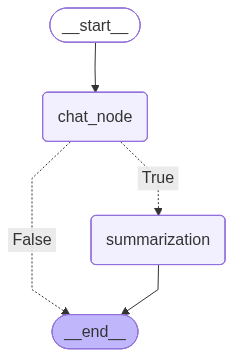

In [17]:
graph = StateGraph(State)
graph.add_node('chat_node',chat_node)
graph.add_node('summarization',summarization)

graph.add_edge(START,'chat_node')
graph.add_conditional_edges('chat_node',should_summarize,{
    True: 'summarization',
    False: END}
)
#graph.add_edge('summarization',END)

graph.compile()

In [19]:
from langgraph.checkpoint.memory import MemorySaver
check = MemorySaver()
workflow = graph.compile(checkpointer = check)

config = {'configurable':{'thread_id':"1"}}



In [ ]:
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [ ]:
final_state = workflow.invoke({'messages':[HumanMessage(content="Quantum Physics")]},config=config)
show_state()

KeyError: 'summary'

In [ ]:
final_state = workflow.invoke({'messages':[HumanMessage(content="Whats the role of albert einstien")]},config=config)
show_state()

In [ ]:
final_state = workflow.invoke({'messages':[HumanMessage(content="Explain theory of relativity")]},config=config)
show_state()

In [ ]:
final_state = workflow.invoke({'messages':[HumanMessage(content="Difference between quantam physics and newton physics")]},config=config)
show_state()

In [ ]:
final_state = workflow.invoke({'messages':[HumanMessage(content="What is honda cars")]},config=config)
show_state()

In [ ]:
final_state = workflow.invoke({'messages':[HumanMessage(content="What is toyota cars")]},config=config)
show_state()

In [21]:
l=[1,2,3,4,5]
print(l[:-2])
print(l[-2:])

[1, 2, 3]
[4, 5]
